In [ ]:
!wget -nc https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv

--2024-04-15 08:03:08--  https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3031::6815:17d2, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2024-04-15 08:03:08 ERROR 403: Forbidden.



In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D, Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.models import Model
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Embedding

In [2]:
df = pd.read_csv('/content/bbc-text.csv')

In [3]:
df

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...
...,...,...
2220,business,cars pull down us retail figures us retail sal...
2221,politics,kilroy unveils immigration policy ex-chatshow ...
2222,entertainment,rem announce new glasgow concert us band rem h...
2223,politics,how political squabbles snowball it s become c...


In [4]:
df['targets'] = df['category'].astype('category').cat.codes

In [5]:
# Number of classes

K = df['targets'].max() + 1
K

5

In [6]:
df_train, df_test = train_test_split(df, test_size = 0.2)

In [7]:
df_train

,category,text,targets
727,tech,anti-spam laws bite spammer hard the net s sel...,4
1832,business,worldcom ex-boss launches defence lawyers defe...,0
647,politics,straw backs ending china embargo uk foreign se...,2
1331,entertainment,glastonbury fans to get id cards fans who buy ...,1
1799,politics,peace demo appeal rejected peace protestors ha...,2
...,...,...,...
68,tech,microsoft gets the blogging bug software giant...,4
425,sport,england coach faces rap after row england coac...,3
542,politics,act on detention ruling uk urged the governme...,2
20,tech,security warning over fbi virus the us feder...,4


In [8]:
class_names = df_train.category.unique()
class_names

array(['tech', 'business', 'politics', 'entertainment', 'sport'],
      dtype=object)

In [9]:
# Convert sentences to sequences

MAX_VOCAB_SIZE = 2000
tokenizer = Tokenizer(num_words =MAX_VOCAB_SIZE )
tokenizer.fit_on_texts(df_train['text'])
sequences_train = tokenizer.texts_to_sequences(df_train['text'])
sequences_test = tokenizer.texts_to_sequences(df_test['text'])


In [10]:
# get word -> integer mapping

word2idx = tokenizer.word_index
V = len(word2idx)
print("Found %s unique tokens."% V)

Found 27118 unique tokens.


In [11]:
# pad sequences so that we gwt a N*T matrix

data_train = pad_sequences(sequences_train)
print('Shape of data train tensor:', data_train.shape)

Shape of data train tensor: (1780, 3559)


In [12]:
# get sequences length

T = data_train.shape[1]

In [13]:
data_test = pad_sequences(sequences_test, maxlen =T)
print('shape of data test tensor:', data_test.shape)

shape of data test tensor: (445, 3559)


In [14]:
D = 20

i = Input(shape =(T,))
x = Embedding(V+1, D)(i)
x = LSTM(32, return_sequences=True)(x)
x = GlobalMaxPooling1D()(x)
x = Dense(K)(x)

model = Model(i,x)

In [15]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 3559)]            0         
                                                                 
 embedding (Embedding)       (None, 3559, 20)          542380    
                                                                 
 lstm (LSTM)                 (None, 3559, 32)          6784      
                                                                 
 global_max_pooling1d (Glob  (None, 32)                0         
 alMaxPooling1D)                                                 
                                                                 
 dense (Dense)               (None, 5)                 165       
                                                                 
Total params: 549329 (2.10 MB)
Trainable params: 549329 (2.10 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________

In [16]:
from keras.optimizers import Adam

model.compile(
    loss = SparseCategoricalCrossentropy(from_logits = True),
    optimizer = Adam(learning_rate = 1e-3),
    metrics = ['accuracy']
)

In [17]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [18]:
print('Training Model')

r = model.fit(
    data_train,
    df_train['targets'],
    epochs=100,
    validation_data=(data_test, df_test['targets']),
    callbacks=[early_stopping]  # Include early stopping callback
)


Training Model
Epoch 1/100
56/56 [==============================] - 26s 404ms/step - loss: 1.5970 - accuracy: 0.2775 - val_loss: 1.5751 - val_accuracy: 0.2629
Epoch 2/100
56/56 [==============================] - 12s 217ms/step - loss: 1.5828 - accuracy: 0.3326 - val_loss: 1.5696 - val_accuracy: 0.2337
Epoch 3/100
56/56 [==============================] - 11s 189ms/step - loss: 1.4688 - accuracy: 0.4837 - val_loss: 1.2856 - val_accuracy: 0.5663
Epoch 4/100
56/56 [==============================] - 9s 170ms/step - loss: 1.0897 - accuracy: 0.6213 - val_loss: 1.0077 - val_accuracy: 0.6719
Epoch 5/100
56/56 [==============================] - 7s 131ms/step - loss: 1.1760 - accuracy: 0.5933 - val_loss: 0.9559 - val_accuracy: 0.6337
Epoch 6/100
56/56 [==============================] - 10s 172ms/step - loss: 0.7097 - accuracy: 0.7781 - val_loss: 0.5821 - val_accuracy: 0.8337
Epoch 7/100
56/56 [==============================] - 9s 154ms/step - loss: 0.4967 - accuracy: 0.8899 - val_loss: 0.6412 - v

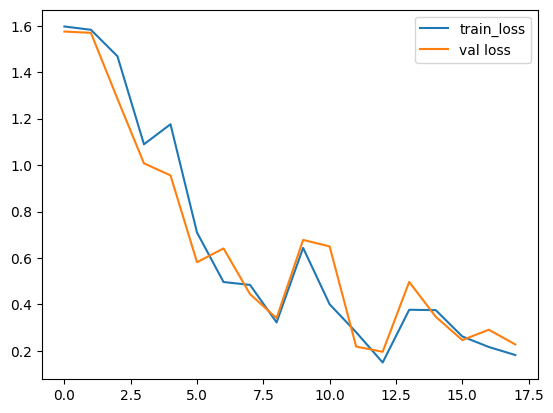

In [19]:
# Plot loss per iteration
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'val loss')
plt.legend()



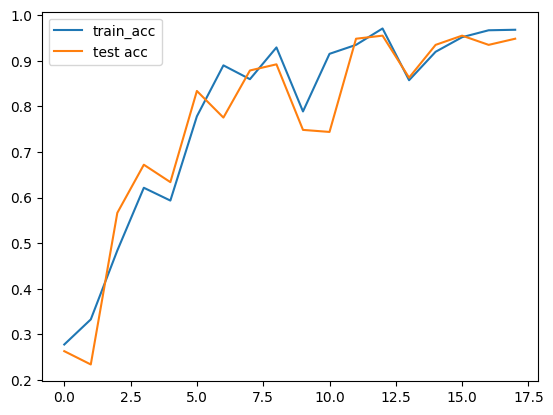

In [20]:
# Plot acc per iteration
plt.plot(r.history['accuracy'], label = 'train_acc')
plt.plot(r.history['val_accuracy'], label = 'test acc')
plt.legend()

In [21]:
train_loss, train_accuracy = model.evaluate(data_train, df_train['targets'])
test_loss, test_accuracy = model.evaluate(data_test, df_test['targets'])

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

14/14 [==============================] - 1s 41ms/step - loss: 0.1962 - accuracy: 0.9551
Train Accuracy: 0.9775
Test Accuracy: 0.9551


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_train_pred = model.predict(data_train)
y_test_pred = model.predict(data_test)


14/14 [==============================] - 1s 46ms/step


In [32]:
# Accuracy
train_accuracy = accuracy_score(df_train['targets'], y_train_pred.argmax(axis=1))
test_accuracy = accuracy_score(df_test['targets'], y_test_pred.argmax(axis=1))

# Precision, Recall, F1-score
train_precision = precision_score(df_train['targets'], y_train_pred.argmax(axis=1), average='macro')
test_precision = precision_score(df_test['targets'], y_test_pred.argmax(axis=1), average='macro')

train_recall = recall_score(df_train['targets'], y_train_pred.argmax(axis=1), average='macro')
test_recall = recall_score(df_test['targets'], y_test_pred.argmax(axis=1), average='macro')

train_f1 = f1_score(df_train['targets'], y_train_pred.argmax(axis=1), average='macro')
test_f1 = f1_score(df_test['targets'], y_test_pred.argmax(axis=1), average='macro')

# model.predict_proba(X_train)  # Replace X_train with your input data





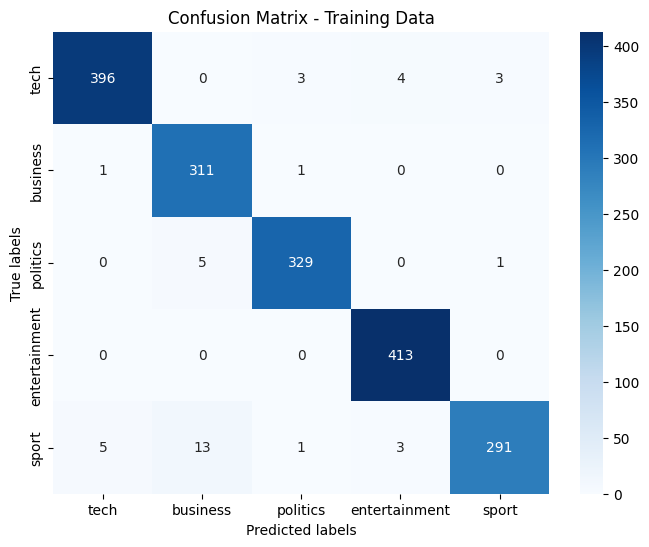

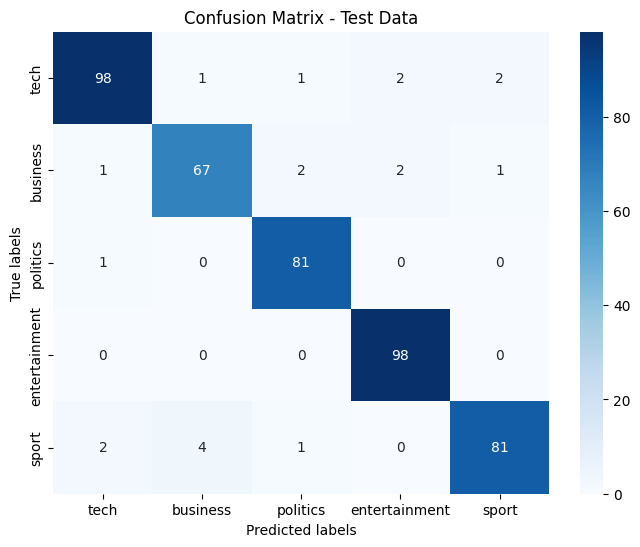

In [33]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.show()

# Define class labels
class_labels = class_names

# Plot confusion matrix for training data
plot_confusion_matrix(df_train['targets'], y_train_pred.argmax(axis=1), labels=class_labels, title='Confusion Matrix - Training Data')

# Plot confusion matrix for test data
plot_confusion_matrix(df_test['targets'], y_test_pred.argmax(axis=1), labels=class_labels, title='Confusion Matrix - Test Data')


In [34]:
from sklearn.metrics import classification_report

# Calculate classification report
train_report = classification_report(df_train['targets'], y_train_pred.argmax(axis=1))
test_report = classification_report(df_test['targets'], y_test_pred.argmax(axis=1))

# Print evaluation metrics
print("Evaluation Metrics - Training Data:")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Train Precision: {train_precision:.4f}")
print(f"Train Recall: {train_recall:.4f}")
print(f"Train F1-score: {train_f1:.4f}")
# print(f"Train AUC-ROC Score: {train_auc:.4f}")

print("\nEvaluation Metrics - Test Data:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
# print(f"Test AUC-ROC Score: {test_auc:.4f}")

# Print classification report
print("\nClassification Report - Training Data:")
print(train_report)

print("\nClassification Report - Test Data:")
print(test_report)


Evaluation Metrics - Training Data:
Train Accuracy: 0.9775
Train Precision: 0.9770
Train Recall: 0.9762
Train F1-score: 0.9763

Evaluation Metrics - Test Data:
Test Accuracy: 0.9551
Test Precision: 0.9539
Test Recall: 0.9537
Test F1-score: 0.9535

Classification Report - Training Data:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       406
           1       0.95      0.99      0.97       313
           2       0.99      0.98      0.98       335
           3       0.98      1.00      0.99       413
           4       0.99      0.93      0.96       313

    accuracy                           0.98      1780
   macro avg       0.98      0.98      0.98      1780
weighted avg       0.98      0.98      0.98      1780


Classification Report - Test Data:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       104
           1       0.93      0.92      0.92        73
           2       0.95  